# Préparation du Dataset MVTec AD — Version Clean

## Objectif
Ce notebook prépare le dataset MVTec AD pour la détection d'anomalies avec un pipeline **propre et reproductible** :

1. **Redimensionnement** de toutes les images à **128×128** (INTER_AREA)
2. **Augmentation** des images d'entraînement (good) pour équilibrer toutes les catégories
3. Organisation dans `Dataset_128/` avec la structure `Train/` et `Test/`

**Différences avec les notebooks précédents :**
- ✅ Pipeline unique et ordonné (redim → augment → organiser)
- ✅ Seed fixe pour reproductibilité
- ✅ Validation visuelle des images augmentées
- ❌ Pas de ground_truth (inutilisés dans ce projet)
- 📁 Dossier de sortie : `Dataset_128/` (distinct des existants)

In [1]:
# Installer les dépendances si besoin
# !pip install opencv-python albumentations tqdm

In [2]:
import os
import random
import shutil
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import albumentations as A
import warnings
warnings.filterwarnings("ignore")

# Seeds pour reproductibilité
np.random.seed(42)
random.seed(42)

print("✅ Imports OK")
print(f"   OpenCV : {cv2.__version__}")
print(f"   Albumentations : {A.__version__}")

✅ Imports OK
   OpenCV : 5.0.0
   Albumentations : 2.0.8


In [3]:
# Chemins et paramètres
SRC_DIR = "Data_Projet_DS"       # Dataset original MVTec AD
DST_DIR = "Dataset_128"          # Dossier de sortie
IMG_SIZE = 128                   # Taille cible : 128×128
IMG_SIZE_TUPLE = (IMG_SIZE, IMG_SIZE)

# Liste des 15 catégories MVTec AD
CATEGORIES = [
    "bottle", "cable", "capsule", "carpet", "grid",
    "hazelnut", "leather", "metal_nut", "pill", "screw",
    "tile", "toothbrush", "transistor", "wood", "zipper"
]

print(f"📁 Source : {SRC_DIR}")
print(f"📁 Destination : {DST_DIR}")
print(f"📏 Taille images : {IMG_SIZE}×{IMG_SIZE}")
print(f"📂 Catégories : {len(CATEGORIES)}")
print(f"🎲 Seed : 42")

📁 Source : Data_Projet_DS
📁 Destination : Dataset_128
📏 Taille images : 128×128
📂 Catégories : 15
🎲 Seed : 42


## Étape 1 : Redimensionnement à 128×128

In [4]:
# Créer la structure de dossiers de destination
# On va créer : Dataset_128/Train/{categorie}/good/  et  Dataset_128/Test/{categorie}/{defaut}/
# On ignore les dossiers ground_truth

DST_TRAIN = os.path.join(DST_DIR, "Train")
DST_TEST = os.path.join(DST_DIR, "Test")
os.makedirs(DST_TRAIN, exist_ok=True)
os.makedirs(DST_TEST, exist_ok=True)

print(f"✅ Structure créée dans {DST_DIR}/")
print(f"   Train → {DST_TRAIN}/")
print(f"   Test  → {DST_TEST}/")

✅ Structure créée dans Dataset_128/
   Train → Dataset_128/Train/
   Test  → Dataset_128/Test/


In [5]:
# Redimensionner et copier toutes les images (sauf ground_truth)
image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')
stats = {}  # Pour compter les images par catégorie

for category in CATEGORIES:
    cat_src = os.path.join(SRC_DIR, category)
    
    # --- Images Train (uniquement good/) ---
    train_src = os.path.join(cat_src, "train", "good")
    if os.path.isdir(train_src):
        dst_train_cat = os.path.join(DST_TRAIN, category, "good")
        os.makedirs(dst_train_cat, exist_ok=True)
        
        count = 0
        for img_name in os.listdir(train_src):
            if img_name.lower().endswith(image_extensions):
                img_path = os.path.join(train_src, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                if img is None:
                    continue
                img_resized = cv2.resize(img, IMG_SIZE_TUPLE, interpolation=cv2.INTER_AREA)
                cv2.imwrite(os.path.join(dst_train_cat, img_name), img_resized)
                count += 1
        stats[(category, "train")] = count

    # --- Images Test (tous les sous-dossiers sauf ground_truth) ---
    test_src = os.path.join(cat_src, "test")
    if os.path.isdir(test_src):
        for defect_type in os.listdir(test_src):
            if defect_type.lower() == "ground_truth":
                continue  # On ignore les ground_truth
            defect_src = os.path.join(test_src, defect_type)
            if not os.path.isdir(defect_src):
                continue
            
            dst_test_cat = os.path.join(DST_TEST, category, defect_type)
            os.makedirs(dst_test_cat, exist_ok=True)
            
            count = 0
            for img_name in os.listdir(defect_src):
                if img_name.lower().endswith(image_extensions):
                    img_path = os.path.join(defect_src, img_name)
                    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                    if img is None:
                        continue
                    img_resized = cv2.resize(img, IMG_SIZE_TUPLE, interpolation=cv2.INTER_AREA)
                    cv2.imwrite(os.path.join(dst_test_cat, img_name), img_resized)
                    count += 1
            stats[(category, f"test/{defect_type}")] = count

print("✅ Redimensionnement terminé !")
print(f"📊 {sum(stats.values())} images au total redimensionnées en {IMG_SIZE}×{IMG_SIZE}")

✅ Redimensionnement terminé !
📊 5354 images au total redimensionnées en 128×128


In [6]:
# Afficher un récapitulatif du redimensionnement
print(f"{'='*70}")
print(f"{'📊 RÉCAPITULATIF — IMAGES REDIMENSIONNÉES':^70}")
print(f"{'='*70}")
print(f"{'Catégorie':<15} {'Train (good)':<15} {'Test':<15} {'Total':<10}")
print(f"{'-'*55}")

grand_total = 0
for cat in CATEGORIES:
    train_count = stats.get((cat, "train"), 0)
    test_keys = [k for k in stats if k[0] == cat and k[1] != "train"]
    test_count = sum(stats[k] for k in test_keys)
    total = train_count + test_count
    grand_total += total
    print(f"{cat:<15} {train_count:<15} {test_count:<15} {total:<10}")

print(f"{'-'*55}")
print(f"{'TOTAL':<15} {sum(stats.get((c,'train'),0) for c in CATEGORIES):<15} {sum(sum(stats[k] for k in stats if k[0]==c and k[1]!='train') for c in CATEGORIES):<15} {grand_total:<10}")
print(f"{'='*70}")

               📊 RÉCAPITULATIF — IMAGES REDIMENSIONNÉES               
Catégorie       Train (good)    Test            Total     
-------------------------------------------------------
bottle          209             83              292       
cable           224             150             374       
capsule         219             132             351       
carpet          280             117             397       
grid            264             78              342       
hazelnut        391             110             501       
leather         245             124             369       
metal_nut       220             115             335       
pill            267             167             434       
screw           320             160             480       
tile            230             117             347       
toothbrush      60              42              102       
transistor      213             100             313       
wood            247             79             

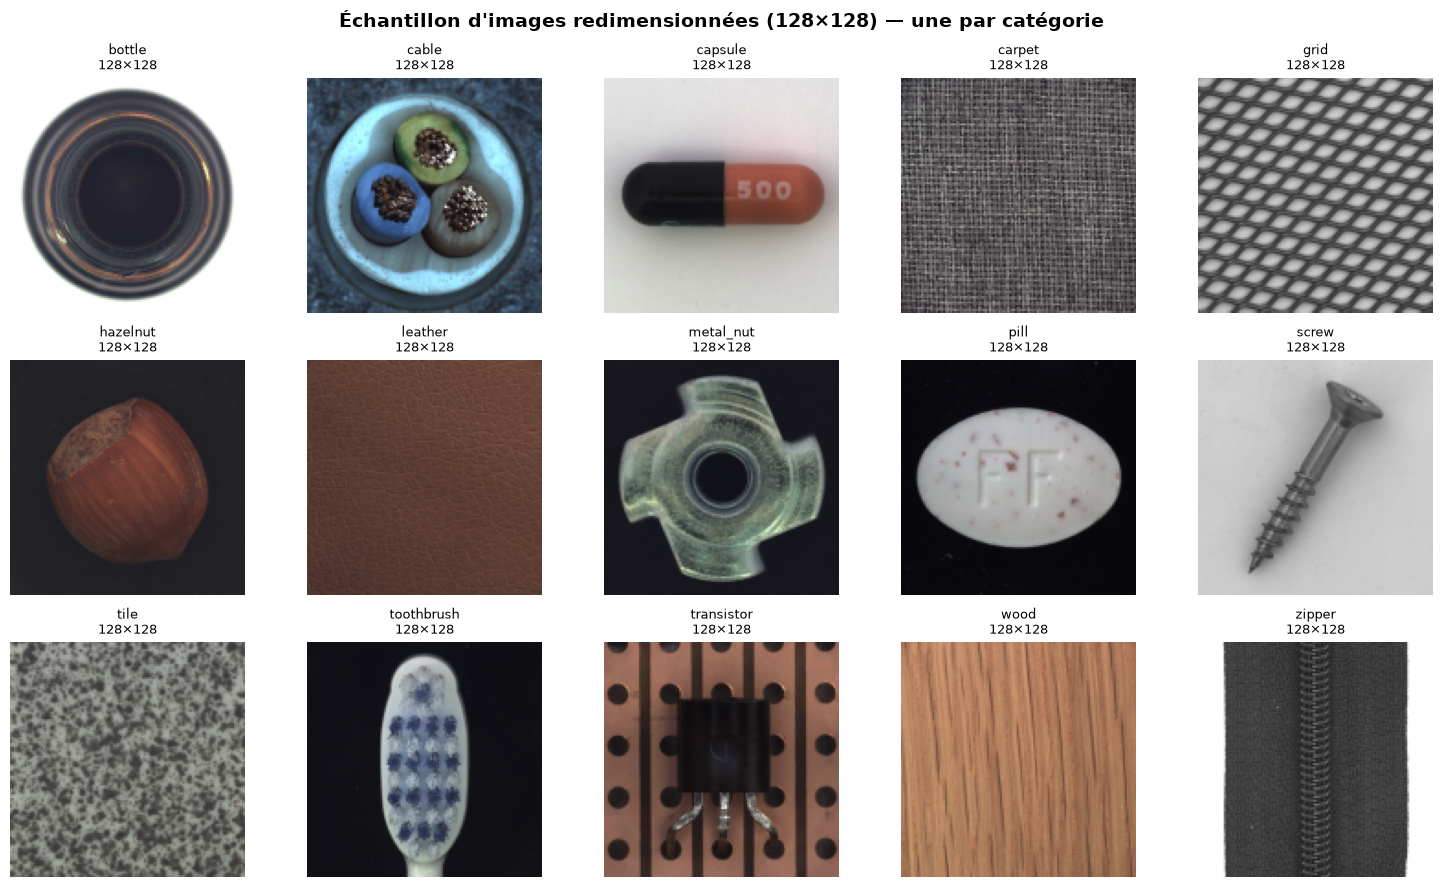

✅ Les images sont bien en 128×128 et les ground_truth ont été ignorés.


In [7]:
# Validation visuelle : échantillon d'images redimensionnées
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Échantillon d'images redimensionnées (128×128) — une par catégorie", fontsize=14, fontweight='bold')

for i, cat in enumerate(CATEGORIES[:15]):
    row, col = i // 5, i % 5
    train_dir = os.path.join(DST_TRAIN, cat, "good")
    if os.path.isdir(train_dir):
        imgs = [f for f in os.listdir(train_dir) if f.lower().endswith(('.png', '.jpg'))]
        if imgs:
            img_sample = cv2.imread(os.path.join(train_dir, imgs[0]))
            img_sample = cv2.cvtColor(img_sample, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img_sample)
            axes[row, col].set_title(f"{cat}\n{img_sample.shape[0]}×{img_sample.shape[1]}", fontsize=9)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()
print(f"✅ Les images sont bien en 128×128 et les ground_truth ont été ignorés.")

## Étape 2 : Augmentation des images d'entraînement

In [8]:
# Pipeline d'augmentation (léger — adapté à la détection d'anomalies)
# Attention : pas de rotation forte ni de distortion agressive
# qui pourrait transformer un défaut en apparence "normale"
#
# border_mode=cv2.BORDER_REFLECT → évite les zones noires après rotation
# en remplissant les vides par réflexion des bords de l'image
# 
# Pas de flip horizontal : certaines catégories ont une orientation
# qui ne peut pas être inversée (bouchon de bouteille, sens du filetage...)

augment = A.Compose([
    A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT, p=0.8),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=cv2.BORDER_REFLECT,
        p=0.8
    ),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.3
    ),
])

print("✅ Pipeline d'augmentation défini (sans flip)")
print(augment)

✅ Pipeline d'augmentation défini (sans flip)
Compose([
  Rotate(p=0.8, border_mode=2, crop_border=False, fill=0.0, fill_mask=0.0, interpolation=1, limit=(-10.0, 10.0), mask_interpolation=0, rotate_method='largest_box'),
  ShiftScaleRotate(p=0.8, shift_limit_x=(-0.05, 0.05), shift_limit_y=(-0.05, 0.05), scale_limit=(-0.050000000000000044, 0.050000000000000044), rotate_limit=(-10.0, 10.0), interpolation=1, border_mode=2, fill=0.0, fill_mask=0.0, rotate_method='largest_box', mask_interpolation=0),
  GaussianBlur(p=0.3, blur_limit=(3, 5), sigma_limit=(0.5, 3.0)),
  RandomBrightnessContrast(p=0.3, brightness_by_max=True, brightness_limit=(-0.1, 0.1), contrast_limit=(-0.1, 0.1), ensure_safe_range=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


In [9]:
# Compter les images train par catégorie
train_counts = {}
for cat in CATEGORIES:
    train_dir = os.path.join(DST_TRAIN, cat, "good")
    if os.path.isdir(train_dir):
        imgs = [f for f in os.listdir(train_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        train_counts[cat] = len(imgs)
    else:
        train_counts[cat] = 0

max_count = max(train_counts.values())
print(f"🎯 Nombre cible d'images train : {max_count} (catégorie la plus fournie)")
print()

# Augmenter chaque catégorie jusqu'à max_count
for cat in CATEGORIES:
    train_dir = os.path.join(DST_TRAIN, cat, "good")
    if not os.path.isdir(train_dir):
        continue
    
    existing = [f for f in os.listdir(train_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    current_count = len(existing)
    to_generate = max_count - current_count
    
    if to_generate <= 0:
        print(f"  {cat:<15} : {current_count} images → OK (déjà au max)")
        continue
    
    print(f"  {cat:<15} : {current_count} images → génération de {to_generate:>3} augmentations...")
    
    for i in range(to_generate):
        # Choisir une image aléatoire parmi les originales
        img_name = random.choice(existing)
        img_path = os.path.join(train_dir, img_name)
        
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        augmented = augment(image=img)["image"]
        
        # Nom unique : aug_0_original.png, aug_1_original.png, ...
        out_name = f"aug_{i:04d}_{img_name}"
        out_path = os.path.join(train_dir, out_name)
        
        cv2.imwrite(out_path, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR))

print()
print("✅ Augmentation terminée !")
print(f"📊 Toutes les catégories ont maintenant {max_count} images train (good)")

🎯 Nombre cible d'images train : 391 (catégorie la plus fournie)

  bottle          : 209 images → génération de 182 augmentations...
  cable           : 224 images → génération de 167 augmentations...
  capsule         : 219 images → génération de 172 augmentations...
  carpet          : 280 images → génération de 111 augmentations...
  grid            : 264 images → génération de 127 augmentations...
  hazelnut        : 391 images → OK (déjà au max)
  leather         : 245 images → génération de 146 augmentations...
  metal_nut       : 220 images → génération de 171 augmentations...
  pill            : 267 images → génération de 124 augmentations...
  screw           : 320 images → génération de  71 augmentations...
  tile            : 230 images → génération de 161 augmentations...
  toothbrush      : 60 images → génération de 331 augmentations...
  transistor      : 213 images → génération de 178 augmentations...
  wood            : 247 images → génération de 144 augmentations...
  

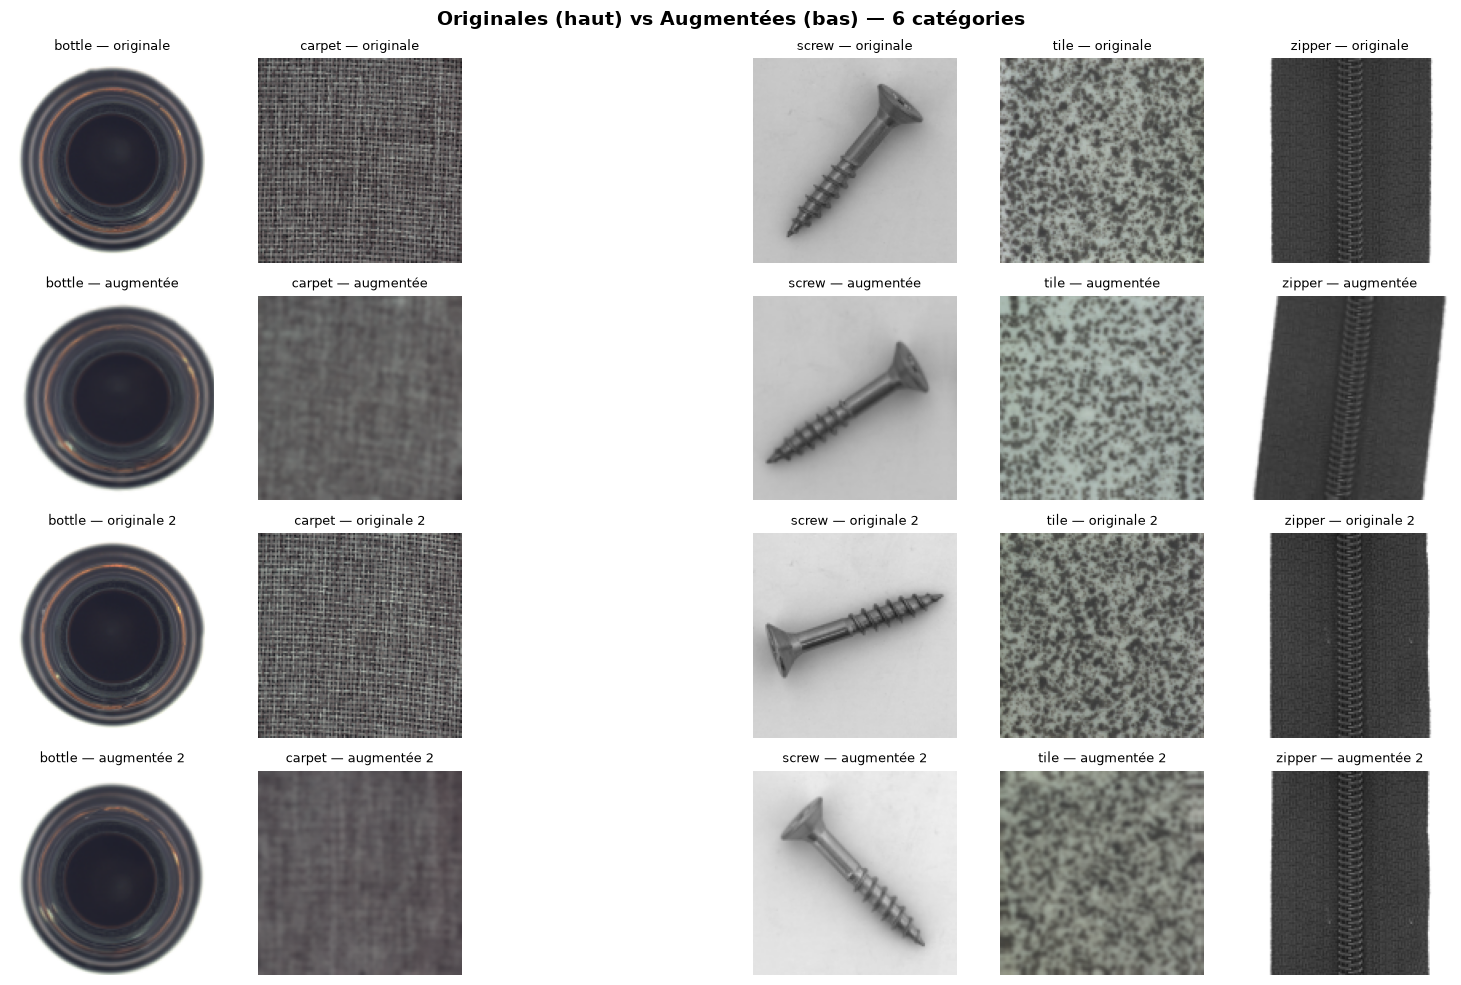

✅ Aucun dossier ground_truth — tout est propre.


In [10]:
# Validation visuelle : comparer originales et augmentées
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
fig.suptitle("Originales (haut) vs Augmentées (bas) — 6 catégories", fontsize=14, fontweight='bold')

sample_cats = ["bottle", "carpet", "hazelnut", "screw", "tile", "zipper"]

for j, cat in enumerate(sample_cats):
    train_dir = os.path.join(DST_TRAIN, cat, "good")
    if not os.path.isdir(train_dir):
        continue
    
    all_imgs = sorted([f for f in os.listdir(train_dir) if f.lower().endswith(('.png', '.jpg'))])
    originals = [f for f in all_imgs if not f.startswith("aug_")]
    augmented = [f for f in all_imgs if f.startswith("aug_")]
    
    if originals and augmented:
        # Image originale
        img_orig = cv2.imread(os.path.join(train_dir, originals[0]))
        img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        axes[0, j].imshow(img_orig)
        axes[0, j].set_title(f"{cat} — originale", fontsize=9)
        
        # Image augmentée
        img_aug = cv2.imread(os.path.join(train_dir, augmented[0]))
        img_aug = cv2.cvtColor(img_aug, cv2.COLOR_BGR2RGB)
        axes[1, j].imshow(img_aug)
        axes[1, j].set_title(f"{cat} — augmentée", fontsize=9)
        
        # Deuxième originale
        if len(originals) > 1:
            img_orig2 = cv2.imread(os.path.join(train_dir, originals[1]))
            img_orig2 = cv2.cvtColor(img_orig2, cv2.COLOR_BGR2RGB)
            axes[2, j].imshow(img_orig2)
            axes[2, j].set_title(f"{cat} — originale 2", fontsize=9)
        
        # Deuxième augmentée
        if len(augmented) > 1:
            img_aug2 = cv2.imread(os.path.join(train_dir, augmented[1]))
            img_aug2 = cv2.cvtColor(img_aug2, cv2.COLOR_BGR2RGB)
            axes[3, j].imshow(img_aug2)
            axes[3, j].set_title(f"{cat} — augmentée 2", fontsize=9)
    
    for k in range(4):
        axes[k, j].axis('off')

plt.tight_layout()
plt.show()

# Vérification finale : aucune image ground_truth
gt_found = False
for root, dirs, files in os.walk(DST_DIR):
    if "ground_truth" in root.lower():
        gt_found = True
        break

if gt_found:
    print("⚠️  Attention : des dossiers ground_truth sont encore présents !")
else:
    print("✅ Aucun dossier ground_truth — tout est propre.")

## Résumé final

In [11]:
# Afficher le résumé final complet
print(f"{'='*70}")
print(f"{'📊 RÉSUMÉ FINAL — Dataset_128':^70}")
print(f"{'='*70}")
print(f"{'Catégorie':<15} {'Train (good)':<18} {'Défauts Test':<20} {'Total':<10}")
print(f"{'-'*63}")

train_total = 0
test_total = 0

for cat in CATEGORIES:
    # Train
    train_dir = os.path.join(DST_TRAIN, cat, "good")
    n_train = len([f for f in os.listdir(train_dir) if f.lower().endswith(('.png', '.jpg'))]) if os.path.isdir(train_dir) else 0
    
    # Test
    test_dir = os.path.join(DST_TEST, cat)
    defect_types = []
    n_test = 0
    if os.path.isdir(test_dir):
        for defect in sorted(os.listdir(test_dir)):
            defect_path = os.path.join(test_dir, defect)
            if os.path.isdir(defect_path):
                n_defect = len([f for f in os.listdir(defect_path) if f.lower().endswith(('.png', '.jpg'))])
                defect_types.append(f"{defect}({n_defect})")
                n_test += n_defect
    
    train_total += n_train
    test_total += n_test
    defects_str = ", ".join(defect_types[:3])
    if len(defect_types) > 3:
        defects_str += f", ... (+{len(defect_types)-3})"
    print(f"{cat:<15} {n_train:<18} {defects_str:<20} {n_train + n_test:<10}")

print(f"{'-'*63}")
print(f"{'TOTAL':<15} {train_total:<18} {test_total:<20} {train_total + test_total:<10}")
print(f"{'='*70}")
print(f"\n📁 Dossier : {DST_DIR}/")
print(f"📏 Taille  : {IMG_SIZE}×{IMG_SIZE}")
print(f"🔢 Images  : {train_total} train + {test_total} test = {train_total + test_total} total")
print(f"🎯 Seed    : 42")
print(f"❌ Ground truth : ignorés")
print(f"\n✅ Dataset prêt !")

                     📊 RÉSUMÉ FINAL — Dataset_128                     
Catégorie       Train (good)       Défauts Test         Total     
---------------------------------------------------------------
bottle          391                broken_large(20), broken_small(22), contamination(21), ... (+1) 474       
cable           391                bent_wire(13), cable_swap(12), combined(11), ... (+6) 541       
capsule         391                crack(23), faulty_imprint(22), good(23), ... (+3) 523       
carpet          391                color(19), cut(17), good(28), ... (+3) 508       
grid            391                bent(12), broken(12), glue(11), ... (+3) 469       
hazelnut        391                crack(18), cut(17), good(40), ... (+2) 501       
leather         391                color(19), cut(19), fold(17), ... (+3) 515       
metal_nut       391                bent(25), color(22), flip(23), ... (+2) 506       
pill            391                color(25), combined(17), cont